In [1]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

# Estimating subthreshold conductance

In [2]:
idxs = np.arange(0, 20)

test_stimulus_1 = 100
test_stimulus_2 = 2500
time_before = 50
time_after = 100

ltp_start = 1000
ltp_duration = 1000

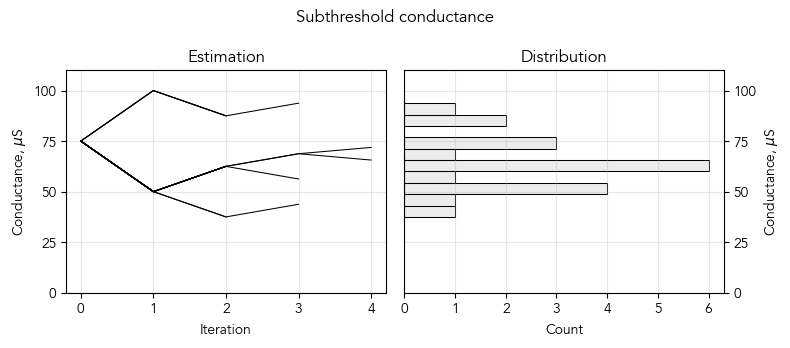

In [3]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 3.5))

final_conductance = []
for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference/subthreshold_conductance/{idx}_results.csv")
    final_conductance.append(results.iloc[-1].Conductance)

    axs[0].plot(
        results.index,
        results.Conductance * 1000_000,
        linewidth = 0.75,
        color = "black"
    )

axs[0].set_xlabel("Iteration")
axs[0].set_ylabel(r"Conductance, $\mu$S")
axs[0].set_ylim(0, 0.00011 * 1000_000)
axs[0].set_yticks(range(0, 125, 25))
axs[0].set_title("Estimation")
axs[0].grid(True, alpha = 0.3)
axs[0].set_xticks(range(0, 5, 1))

axs[1].hist(np.array(final_conductance) * 1000_000, bins = 10, orientation = "horizontal", facecolor = (0, 0, 0, 0.075), edgecolor = "black", linewidth = 0.75)
axs[1].set_ylabel(r"Conductance, $\mu$S")
axs[1].set_xlabel("Count")
axs[1].set_title("Distribution")
axs[1].set_ylim(0, 110)
axs[1].set_yticks(range(0, 125, 25))
axs[1].grid(True, alpha = 0.3)
axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()

fig.suptitle("Subthreshold conductance")
fig.tight_layout()
plt.show()

Subthreshold conductance was estimated in such a way that there would be no action potentials before or after LTP protocol; during LTP induction, the synapses generate dendritic spikes (but not necessarily somatic spikes).

In [76]:
conditions = {
    "No TI": "subthreshold_conductance/ltp/noTI_0.1",
    # "5 Hz": "subthreshold_conductance/ltp/1000_5_0.9_0.1",
    # "130 Hz": "subthreshold_conductance/ltp/1000_130_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    # "5 Hz": "tab:orange",
    # "130 Hz": "tab:green"
}

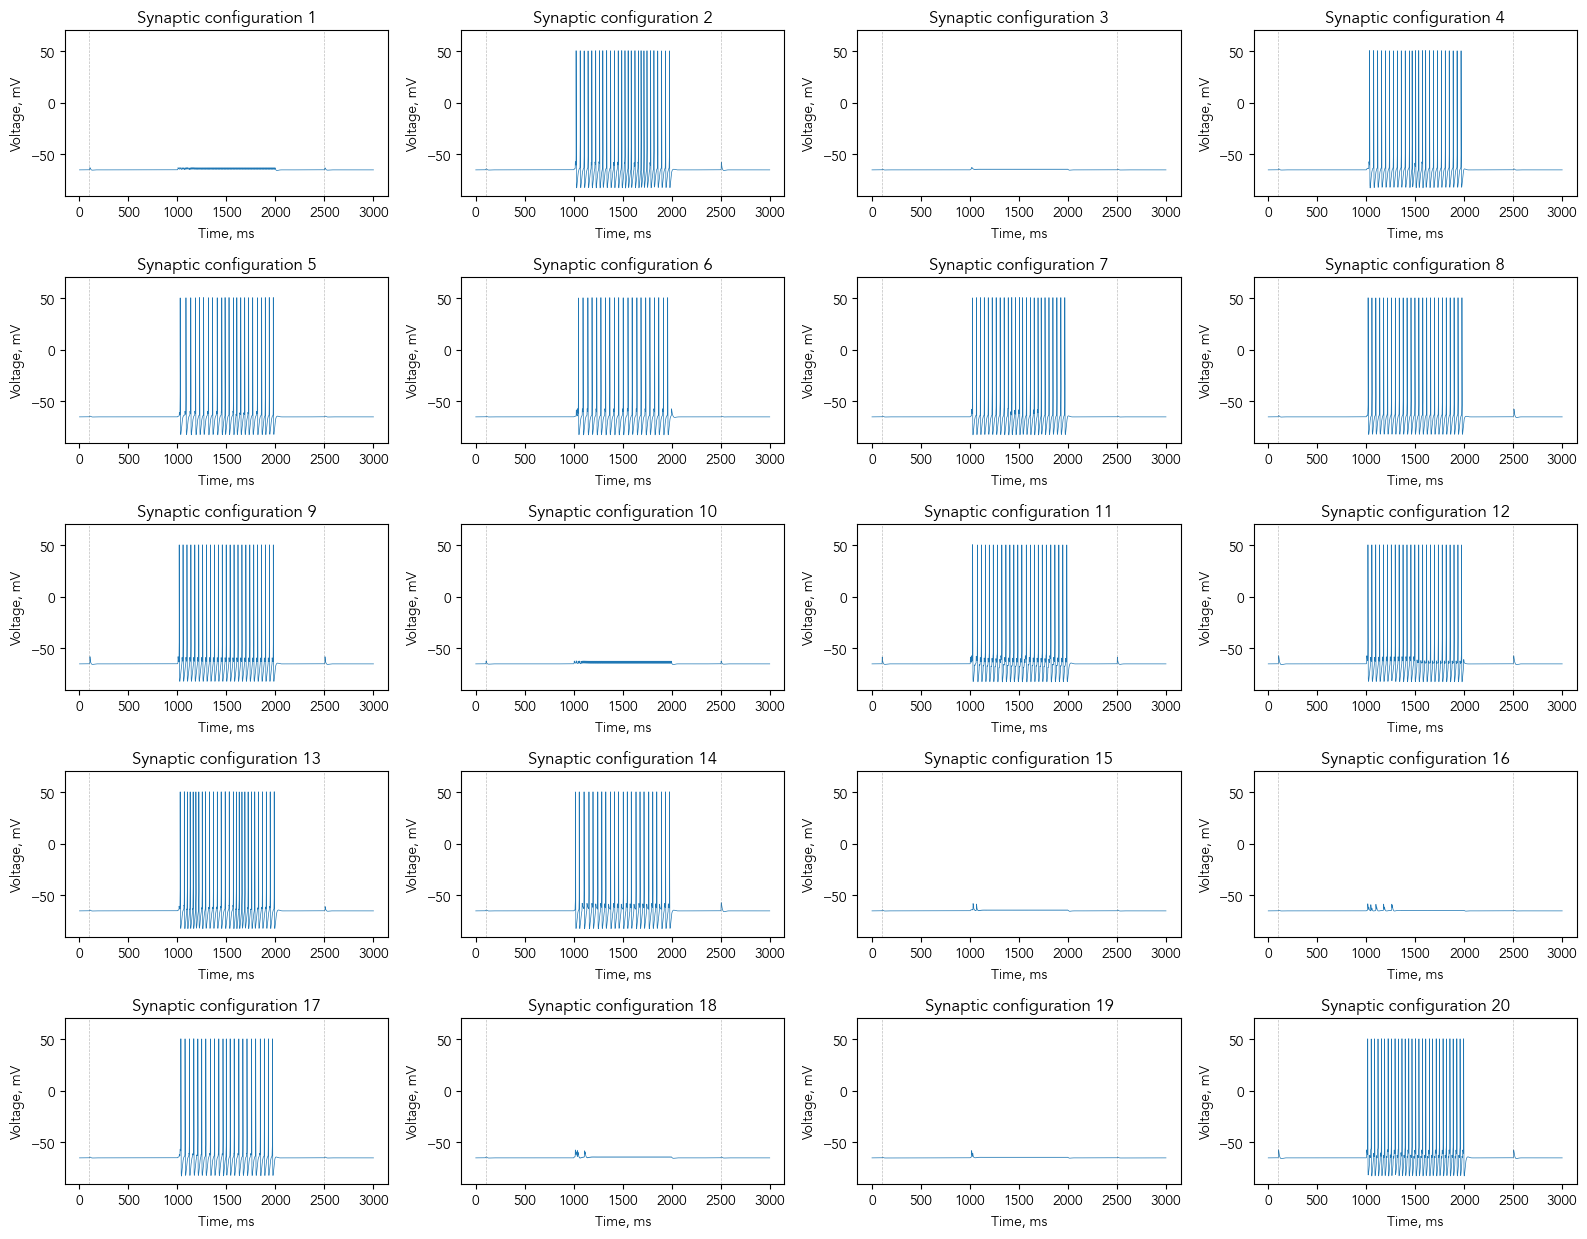

In [77]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (16, int(len(idxs) / 4) * 2.5))
axs = axs.flatten()

for idx, ax in zip(idxs, axs):
    for condition in conditions.keys():
        filename = conditions[condition]
        color = colors[condition]
        
        voltage = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/voltage.csv")

        ax.plot(
            voltage.Time,
            voltage.Voltage,
            linewidth = 0.5,
            color = color
        )

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-90, 70)

    ax.set_title(f"Synaptic configuration {idx + 1}")
    
    ax.axvline(test_stimulus_1, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)
    ax.axvline(test_stimulus_2, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)

fig.tight_layout()
plt.show()

In [78]:
def match_array_size(*arrays):
    min_len = min(arr.shape[0] for arr in arrays)
    return [arr[:min_len] for arr in arrays]

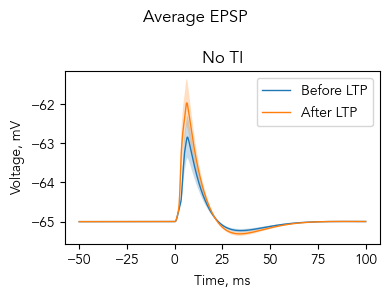

In [81]:
fig, axs = plt.subplots(nrows = 1, ncols = len(conditions), figsize = (4 * len(conditions), 3))
axs = np.array(axs)
axs = axs.flatten()

for i, condition in enumerate(conditions.keys()):
    filename = conditions[condition]
    color = colors[condition]
    
    epsp_before = []
    epsp_after = []
    
    for idx in idxs:
        voltage = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/voltage.csv")
        
        time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
        epsp_before.append(voltage.Voltage[time_epsp_before].tolist())
        
        time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
        epsp_after.append(voltage.Voltage[time_epsp_after].tolist())

    time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())

    epsp_before = np.array(epsp_before).T
    epsp_after = np.array(epsp_after).T

    time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

    mean = epsp_before.mean(axis = 1)
    error = epsp_before.std(axis = 1)  / np.sqrt(epsp_before.shape[1])

    axs[i].plot(
        time,
        mean,
        linewidth = 1,
        label = "Before LTP"
    )
    axs[i].fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    mean = epsp_after.mean(axis = 1)
    error = epsp_after.std(axis = 1) / np.sqrt(epsp_after.shape[1])

    axs[i].plot(
        time,
        mean,
        linewidth = 1,
        label = "After LTP"
    )
    axs[i].fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Voltage, mV")
    axs[i].set_title(condition)
    axs[i].legend()

fig.suptitle("Average EPSP")
fig.tight_layout()
plt.show()